Projet Machine Learning

In [23]:
%pip install pandas numpy requests pandas_datareader gdeltdoc scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
from pandas_datareader import data as pdr
import datetime

# Période d'étude
start = datetime.datetime(2018,4,1)
end = datetime.datetime(2020,6,30)

# Bund 10Y (Allemagne)
bund = pdr.DataReader("IRLTLT01DEM156N", "fred", start, end)
# ticker : IRLTLT01DEM156N : serie mensuelle de fred : data base de la FED

# France 10Y
france = pdr.DataReader("IRLTLT01FRM156N", "fred", start, end)

# Construction du spread
spread = france.iloc[:,0] - bund.iloc[:,0]
spread = spread.to_frame(name="spread")

spread.head()

,spread
DATE,
2018-04-01,0.300000
2018-05-01,0.340000
2018-06-01,0.422857
2018-07-01,0.395455
2018-08-01,0.409130


In [4]:
# Variation mensuelle (regression : delta)
spread["delta"] = spread["spread"].diff()

spread.head() #head affiche que les 5 premieres lignes 

,spread,delta
DATE,,
2018-04-01,0.300000,NaN
2018-05-01,0.340000,0.040000
2018-06-01,0.422857,0.082857
2018-07-01,0.395455,-0.027403
2018-08-01,0.409130,0.013676


In [ ]:
# Direction du spread = 1 : spread monte // = 0 : baisse (classification)
spread["direction"] = (spread["delta"] > 0).astype(int)

spread.head()

,spread,delta,direction
DATE,,,
2018-04-01,0.300000,NaN,0
2018-05-01,0.340000,0.040000,1
2018-06-01,0.422857,0.082857,1
2018-07-01,0.395455,-0.027403,0
2018-08-01,0.409130,0.013676,1


In [6]:
# Volatilité glissante sur 6 mois du spread (rolling std)
spread["vol_6m"] = spread["delta"].rolling(6).std()
spread.head()

,spread,delta,direction,vol_6m
DATE,,,,
2018-04-01,0.300000,NaN,0,NaN
2018-05-01,0.340000,0.040000,1,NaN
2018-06-01,0.422857,0.082857,1,NaN
2018-07-01,0.395455,-0.027403,0,NaN
2018-08-01,0.409130,0.013676,1,NaN


In [21]:
# Import news 

import pandas as pd

news_df = pd.read_csv("../data/reuters_headlines.csv")
#news_df = pd.read_csv("../data/us_economic_news.csv", encoding="latin1")

news_df.head()

news_df.columns

Index(['Headlines', 'Time', 'Description'], dtype='object')

In [22]:
# Construire texte complet
news_df["text"] = (
    news_df["Headlines"].fillna("") + " " +
    news_df["Description"].fillna("")
)

news_df["text"] = news_df["text"].str.lower()


# Transformer la date (att° regarde la période exacte (probablement 2017–2020)
news_df["Time"] = pd.to_datetime(news_df["Time"])
news_df["month"] = news_df["Time"].dt.to_period("M")

news_df["month"].min(), news_df["month"].max()

# Definir les mots-clés macro
inflation_words = [
    "inflation", "price pressure", "cpi", "hike",
    "rate increase", "monetary policy", "hawkish",
    "dovish", "tightening", "ecb"
]

risk_words = [
    "crisis", "recession", "debt", "deficit",
    "default", "downgrade", "risk premium",
    "volatility", "instability"
]

growth_words = [
    "recovery", "expansion", "gdp", "growth",
    "unemployment", "employment"
]

geopolitical_words = [
    "war", "conflict", "energy shock",
    "gas", "sanctions"
]

# Fonction de comptage 
def count_keywords(text, keywords):
    return sum(text.count(word) for word in keywords)

# Creer les indices : 
news_df["macro_inflation_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, inflation_words)
)

news_df["macro_risk_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, risk_words)
)

news_df["growth_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, growth_words)
)

news_df["geopolitical_index"] = news_df["text"].apply(
    lambda x: count_keywords(x, geopolitical_words)
)

# Agregation mensuelle 
monthly_indices = news_df.groupby("month")[[
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]].sum()

monthly_indices.head()

,macro_inflation_index,macro_risk_index,growth_index,geopolitical_index
month,,,,
2018-03,26,25,23,110
2018-04,66,35,70,231
2018-05,39,46,61,205
2018-06,70,41,82,257
2018-07,49,35,103,245


In [9]:
## Preparer le spread mensuel

# 1) convertir index en datetime si besoin
spread.index = pd.to_datetime(spread.index)

# 2️) passer en mensuel (moyenne du mois)
spread_monthly = spread.resample("M").mean()

# 3️) créer variable month compatible avec news
spread_monthly["month"] = spread_monthly.index.to_period("M")

spread_monthly.head()

,spread,delta,direction,vol_6m,month
DATE,,,,,
2018-04-30,0.300000,NaN,0.0,NaN,2018-04
2018-05-31,0.340000,0.040000,1.0,NaN,2018-05
2018-06-30,0.422857,0.082857,1.0,NaN,2018-06
2018-07-31,0.395455,-0.027403,0.0,NaN,2018-07
2018-08-31,0.409130,0.013676,1.0,NaN,2018-08


In [10]:
# Merge news + spread
data_final = spread_monthly.merge(
    monthly_indices,
    on="month",
    how="left"
)

data_final.fillna(0, inplace=True)

data_final.head()

,spread,delta,direction,vol_6m,month,macro_inflation_index,macro_risk_index,growth_index,geopolitical_index
0,0.300000,0.000000,0.0,0.0,2018-04,66,35,70,231
1,0.340000,0.040000,1.0,0.0,2018-05,39,46,61,205
2,0.422857,0.082857,1.0,0.0,2018-06,70,41,82,257
3,0.395455,-0.027403,0.0,0.0,2018-07,49,35,103,245
4,0.409130,0.013676,1.0,0.0,2018-08,32,51,87,152


In [ ]:
# Partie Machine Learning
# Creer la target 

data_final["delta"] = data_final["spread"].diff()

data_final["direction"] = (data_final["delta"] > 0).astype(int)

data_final.head()

,spread,delta,direction,vol_6m,month,macro_inflation_index,macro_risk_index,growth_index,geopolitical_index
0,0.300000,NaN,0,0.0,2018-04,66,35,70,231
1,0.340000,0.040000,1,0.0,2018-05,39,46,61,205
2,0.422857,0.082857,1,0.0,2018-06,70,41,82,257
3,0.395455,-0.027403,0,0.0,2018-07,49,35,103,245
4,0.409130,0.013676,1,0.0,2018-08,32,51,87,152


In [12]:
# Preparer X et y
features = [
    "macro_inflation_index",
    "macro_risk_index",
    "growth_index",
    "geopolitical_index"
]

X = data_final[features]
y = data_final["direction"]

In [26]:
# Modele ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.67      0.50      0.57         4

    accuracy                           0.67         9
   macro avg       0.67      0.65      0.65         9
weighted avg       0.67      0.67      0.66         9



In [14]:
#Importance economique 
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importance

macro_risk_index         0.317203
growth_index             0.248447
macro_inflation_index    0.235366
geopolitical_index       0.198984
dtype: float64

In [24]:
# Standardisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Logistic Regression (baseline linéaire)
# Compare RF vs modèle économique simple

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

# Si : RF >> logistic → non-linéarités

Logistic Regression
              precision    recall  f1-score   support

           0       0.50      0.80      0.62         5
           1       0.00      0.00      0.00         4

    accuracy                           0.44         9
   macro avg       0.25      0.40      0.31         9
weighted avg       0.28      0.44      0.34         9



In [27]:
# Cross-Validation Time Series
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=tscv)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

CV scores: [0.5  0.25 0.   1.   0.5 ]
Mean accuracy: 0.45


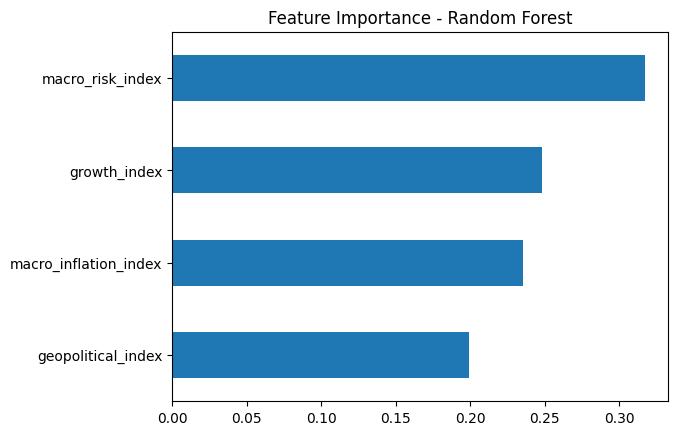

In [28]:
# Graphique importance : 

import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

plt.figure()
importance.plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.show()

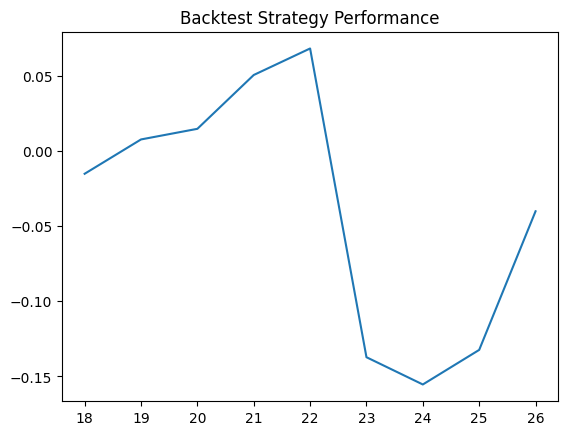

In [30]:
# Backtest : y_pred = 1 → spread monte // y_pred = 0 → spread baisse

backtest = data_final.iloc[len(X_train):].copy()
backtest["pred"] = y_pred

backtest["strategy_return"] = (
    (backtest["pred"] * 2 - 1) * backtest["delta"]
)

backtest["cum_return"] = backtest["strategy_return"].cumsum()

plt.figure()
backtest["cum_return"].plot()
plt.title("Backtest Strategy Performance")
plt.show()

AUC: 0.55


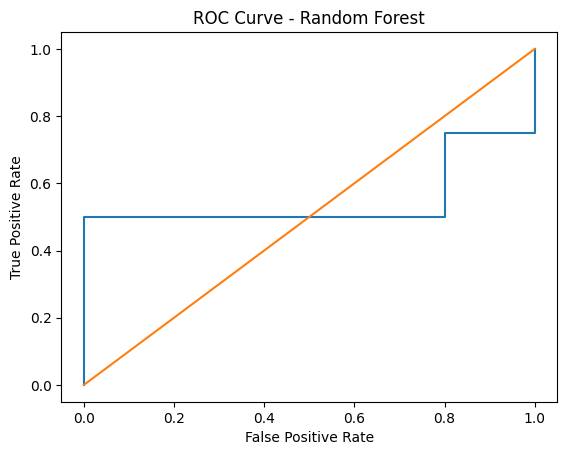

In [31]:
# ROC Curve + AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilités
y_proba = model.predict_proba(X_test)[:, 1]

# AUC
auc_score = roc_auc_score(y_test, y_proba)
print("AUC:", auc_score)

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [32]:
# baseline naif
import numpy as np
from sklearn.metrics import accuracy_score

# Baseline : toujours prédire 0 (spread baisse)
y_baseline = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, y_baseline)
model_accuracy = accuracy_score(y_test, y_pred)

print("Baseline accuracy:", baseline_accuracy)
print("Model accuracy:", model_accuracy)

Baseline accuracy: 0.5555555555555556
Model accuracy: 0.6666666666666666


In [33]:
# Rolling Out-of-Sample Backtest
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

rolling_preds = []
rolling_real = []
rolling_dates = []

window_size = 24  # 24 mois train

for i in range(window_size, len(X)):
    
    X_train_roll = X.iloc[i-window_size:i]
    y_train_roll = y.iloc[i-window_size:i]
    
    X_test_roll = X.iloc[i:i+1]
    y_test_roll = y.iloc[i:i+1]
    
    model_roll = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    
    model_roll.fit(X_train_roll, y_train_roll)
    
    pred = model_roll.predict(X_test_roll)
    
    rolling_preds.append(pred[0])
    rolling_real.append(y_test_roll.values[0])
    rolling_dates.append(X.index[i])

# DataFrame résultats
rolling_df = pd.DataFrame({
    "real": rolling_real,
    "pred": rolling_preds
}, index=rolling_dates)

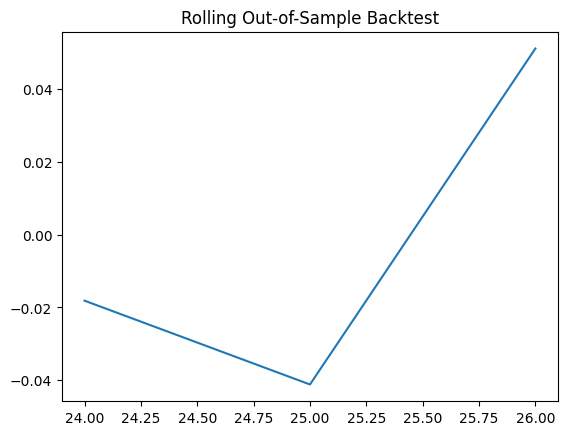

In [34]:
# Backtest économiquement cohérent
rolling_df["delta"] = data_final.loc[rolling_df.index, "delta"]

rolling_df["strategy_return"] = (
    (rolling_df["pred"] * 2 - 1) * rolling_df["delta"]
)

rolling_df["cum_return"] = rolling_df["strategy_return"].cumsum()

plt.figure()
rolling_df["cum_return"].plot()
plt.title("Rolling Out-of-Sample Backtest")
plt.show()

In [15]:
# savoir quel environnement on est pour python : avoir venv
import sys
print(sys.executable)

/Users/marion/ml-news-spread/venv/bin/python
